In [1]:
import anndata
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ImportError: Numba needs NumPy 1.24 or less

In [4]:
adata = sc.read_h5ad("srivatsan20_sciplex3_w_emb.h5ad", backed="r")

In [5]:
adata = adata[adata.obs["cell_line"] != "NA"].to_memory()

In [6]:
control = adata[adata.obs["pert_compound"] == "control"]
treated = adata[adata.obs["pert_compound"] != "control"]
#treated = treated[treated.obs["cell_line"] != "NA"]
print(treated.obs["cell_line"].value_counts())

print(f"Control cells: {control.n_obs}")
print(f"Treated cells: {treated.n_obs}")

cell_line
MCF7     323651
A549     228359
K-562    163076
Name: count, dtype: int64
Control cells: 17578
Treated cells: 715086


In [7]:
print(control.obs["cell_line"].value_counts())
print(treated.obs["cell_line"].value_counts())

cell_line
MCF7     7786
A549     5857
K-562    3935
Name: count, dtype: int64
cell_line
MCF7     323651
A549     228359
K-562    163076
Name: count, dtype: int64


In [8]:
print(adata.obs.columns.tolist())

['pert_target', 'pert_compound', 'pert_dose', 'pert_time', 'organism', 'cell_line', 'cell_type', 'disease', 'tissue_type', 'tissue', 'assay', 'suspension_type', 'donor_id', 'sex', 'self_reported_ethnicity', 'development_stage', 'pert_name', 'pert_type', 'ncounts', 'well', 'plate', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'pathway', 'dose_unit', 'cancer', 'drug_org', 'drug_0', 'drug_1']


In [9]:
adata.obs[["cell_line", "pert_compound", "dose_value", "time", "plate", "well"]].drop_duplicates().head(10)

,cell_line,pert_compound,dose_value,time,plate,well
A01_E09_RT_BC_100_Lig_BC_147,MCF7,TAK-901,10000.0,24.0,plate44,plate6_A9
A01_E09_RT_BC_100_Lig_BC_186,MCF7,AG-490,10.0,24.0,plate46,plate8_H3
A01_E09_RT_BC_100_Lig_BC_196,MCF7,abexinostat,1000.0,24.0,plate41,plate3_C2
A01_E09_RT_BC_100_Lig_BC_213,A549,alisertib,1000.0,72.0,plate51,plate9_E3
A01_E09_RT_BC_100_Lig_BC_220,K-562,busulfan,10000.0,24.0,plate30,plate8_H10
A01_E09_RT_BC_100_Lig_BC_227,MCF7,Obatoclax,100.0,24.0,plate47,plate9_G9
A01_E09_RT_BC_100_Lig_BC_245,A549,Enzastaurin,1000.0,24.0,plate39,plate9_C3
A01_E09_RT_BC_100_Lig_BC_254,MCF7,BMS-265246,100.0,24.0,plate47,plate9_H11
A01_E09_RT_BC_100_Lig_BC_289,K-562,UNC0379,1000.0,24.0,plate27,plate5_A6
A01_E09_RT_BC_100_Lig_BC_306,A549,Raltitrexed,10.0,24.0,plate40,plate10_D6


In [10]:
cell_line = "MCF7"
drug = "ruxolitinib"

initial = adata.obs[
    (adata.obs["cell_line"] == cell_line) & 
    (adata.obs["pert_compound"] == "control")
]

In [11]:
adata.obs.columns

Index(['pert_target', 'pert_compound', 'pert_dose', 'pert_time', 'organism',
       'cell_line', 'cell_type', 'disease', 'tissue_type', 'tissue', 'assay',
       'suspension_type', 'donor_id', 'sex', 'self_reported_ethnicity',
       'development_stage', 'pert_name', 'pert_type', 'ncounts', 'well',
       'plate', 'replicate', 'time', 'dose_value', 'pathway_level_1',
       'pathway_level_2', 'pathway', 'dose_unit', 'cancer', 'drug_org',
       'drug_0', 'drug_1'],
      dtype='object')

In [12]:
plate_adata = adata[(adata.obs["plate"] == "plate1") & (adata.obs["well"] == "plate3_A1")].copy()

In [13]:
cell_line = "MCF7"
drug = "ruxolitinib"

initial = adata.obs[
    (adata.obs["cell_line"] == cell_line) & 
    (adata.obs["pert_compound"] == "control")
]

final = adata.obs[
    (adata.obs["cell_line"] == cell_line) & 
    (adata.obs["pert_compound"] == drug)
]

print(f"Initial (control): {len(initial)} cells")
print(f"Final (treated):   {len(final)} cells")

Initial (control): 7786 cells
Final (treated):   2156 cells


In [14]:
initial

,pert_target,pert_compound,pert_dose,pert_time,organism,cell_line,cell_type,disease,tissue_type,tissue,...,time,dose_value,pathway_level_1,pathway_level_2,pathway,dose_unit,cancer,drug_org,drug_0,drug_1
A01_E09_RT_BC_117_Lig_BC_76,Vehicle,control,0.0nM,24h,human,MCF7,mammary gland epithelial cell,breast adenocarcinoma,cell culture,breast,...,24.0,0.0,Vehicle,Vehicle,Vehicle,nM,True,control,control,control
A01_E09_RT_BC_122_Lig_BC_152,Vehicle,control,0.0nM,24h,human,MCF7,mammary gland epithelial cell,breast adenocarcinoma,cell culture,breast,...,24.0,0.0,Vehicle,Vehicle,Vehicle,nM,True,control,control,control
A01_E09_RT_BC_13_Lig_BC_378,Vehicle,control,0.0nM,24h,human,MCF7,mammary gland epithelial cell,breast adenocarcinoma,cell culture,breast,...,24.0,0.0,Vehicle,Vehicle,Vehicle,nM,True,control,control,control
A01_E09_RT_BC_144_Lig_BC_298,Vehicle,control,0.0nM,24h,human,MCF7,mammary gland epithelial cell,breast adenocarcinoma,cell culture,breast,...,24.0,0.0,Vehicle,Vehicle,Vehicle,nM,True,control,control,control
A01_E09_RT_BC_154_Lig_BC_8,Vehicle,control,0.0nM,24h,human,MCF7,mammary gland epithelial cell,breast adenocarcinoma,cell culture,breast,...,24.0,0.0,Vehicle,Vehicle,Vehicle,nM,True,control,control,control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H12_F10_RT_BC_66_Lig_BC_183,Vehicle,control,0.0nM,24h,human,MCF7,mammary gland epithelial cell,breast adenocarcinoma,cell culture,breast,...,24.0,0.0,Vehicle,Vehicle,Vehicle,nM,True,control,control,control
H12_F10_RT_BC_81_Lig_BC_137,Vehicle,control,0.0nM,24h,human,MCF7,mammary gland epithelial cell,breast adenocarcinoma,cell culture,breast,...,24.0,0.0,Vehicle,Vehicle,Vehicle,nM,True,control,control,control
H12_F10_RT_BC_81_Lig_BC_275,Vehicle,control,0.0nM,24h,human,MCF7,mammary gland epithelial cell,breast adenocarcinoma,cell culture,breast,...,24.0,0.0,Vehicle,Vehicle,Vehicle,nM,True,control,control,control
H12_F10_RT_BC_82_Lig_BC_327,Vehicle,control,0.0nM,24h,human,MCF7,mammary gland epithelial cell,breast adenocarcinoma,cell culture,breast,...,24.0,0.0,Vehicle,Vehicle,Vehicle,nM,True,control,control,control


In [15]:
results = []

for (drug, cell_line), group in treated.obs.groupby(["pert_compound", "cell_line"]):
    ctrl = control.obs[control.obs["cell_line"] == cell_line].index
    treat = group.index
    
    ctrl_mean = adata[ctrl].X.mean(axis=0)
    treat_mean = adata[treat].X.mean(axis=0)
    
    delta = np.array(treat_mean - ctrl_mean).flatten()
    euclidean = np.linalg.norm(delta)
    
    results.append({
        "drug": drug,
        "cell_line": cell_line,
        "n_control": len(ctrl),
        "n_treated": len(treat),
        "euclidean_dist": euclidean
    })

results_df = pd.DataFrame(results)
print(results_df.head())
results_df.to_csv("drug_expression_changes.csv", index=False)

/tmp/ipykernel_3281793/290793651.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (drug, cell_line), group in treated.obs.groupby(["pert_compound", "cell_line"]):


                 drug cell_line  n_control  n_treated  euclidean_dist
0  2-Methoxyestradiol      A549       5857       2428       79.718638
1  2-Methoxyestradiol     K-562       3935        738        5.690378
2  2-Methoxyestradiol      MCF7       7786       1843       13.202231
3               A-366      A549       5857        982       17.026550
4               A-366     K-562       3935       1057       11.893386


In [16]:
ic50_df = pd.read_csv("ic50_data.csv")

adata_drugs = set(treated.obs["pert_compound"].str.lower().str.strip().unique())
ic50_drugs = set(ic50_df["drug"].str.lower().str.strip().unique())

common = adata_drugs & ic50_drugs
print(f"Common drugs: {len(common)} / {len(adata_drugs)}")
print(common)

Common drugs: 82 / 180
{'rucaparib', 'trametinib', 'lenalidomide', 'regorafenib', 'filgotinib', 'luminespib', 'vandetanib', 'danusertib', 'costunolide', 'temsirolimus', 'curcumin', 'amisulpride', 'mk-5108', 'cediranib', 'pelitinib', 'carmofur', 'momelotinib', 'fasudil', 'nilotinib', 'sirtinol', 'daphnetin', 'roscovitine', 'thalidomide', 'pirarubicin', 'fulvestrant', 'pha-680632', 'avagacestat', 'mocetinostat', 'barasertib', 'alvespimycin', 'bosutinib', 'sorafenib', 'ar-42', 'rigosertib', 'linifanib', 'cudc-101', 'raltitrexed', 'prednisone', 'capecitabine', '2-methoxyestradiol', 'toremifene', 'tozasertib', 'azacitidine', 'nintedanib', 'belinostat', 'panobinostat', 'maraviroc', 'tranylcypromine', 'navitoclax', 'tofacitinib', 'pfi-1', 'zileuton', 'resveratrol', 'entinostat', 'quercetin', 'tazemetostat', 'busulfan', 'dacinostat', 'sgi-1776', 'jnj-7706621', 'disulfiram', 'fluorouracil', 'thiotepa', 'whi-p154', 'pd173074', 'bms-754807', 'ki8751', 'tacedinaline', 'cimetidine', 'aminoglutethim

In [17]:
results_df["drug_norm"] = results_df["drug"].str.lower().str.strip()
ic50_df["drug_norm"] = ic50_df["drug"].str.lower().str.strip()
ic50_mean = ic50_df[ic50_df["units"] == "nM"].groupby("drug_norm")["ic50"].mean().rename("mean_ic50_nM")
merged = results_df[results_df["drug_norm"].isin(common)].join(ic50_mean, on="drug_norm").dropna(subset=["mean_ic50_nM"])

In [20]:
merged["log_ic50"] = np.log10(merged["mean_ic50_nM"])
merged_avg = merged.groupby("drug_norm")[["euclidean_dist", "log_ic50"]].mean().reset_index()

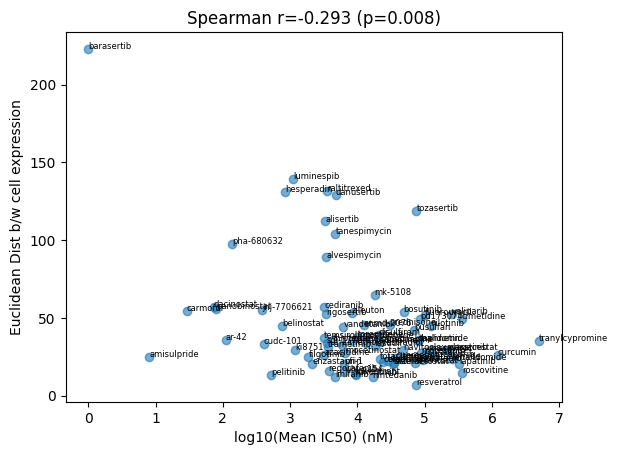

In [33]:
r, p = stats.spearmanr(merged_avg["euclidean_dist"], merged_avg["log_ic50"])
plt.scatter(merged_avg["log_ic50"], merged_avg["euclidean_dist"], alpha=0.6)
for _, row in merged_avg.iterrows():
    plt.annotate(row["drug_norm"], (row["log_ic50"], row["euclidean_dist"]), fontsize=6)
plt.xlabel("log10(Mean IC50) (nM)"); plt.ylabel("Euclidean Dist b/w cell expression"); plt.title(f"Spearman r={r:.3f} (p={p:.3f})"); plt.show()

In [42]:
matched = pd.read_csv("matched_drugs_all_info.csv")[["drug", "chembl_id"]].dropna()
matched["drug_norm"] = matched["drug"].str.lower().str.strip()

merged = merged.merge(matched[["drug_norm", "chembl_id"]], on="drug_norm", how="left")
print(f"Drugs with chembl_id: {merged['chembl_id'].notna().sum()} / {len(merged)}")

Drugs with chembl_id: 243 / 243


In [43]:
merged

,drug,cell_line,n_control,n_treated,euclidean_dist,drug_norm,mean_ic50_nM,log_ic50,chembl_id
0,2-Methoxyestradiol,A549,5857,2428,79.718638,2-methoxyestradiol,5804.974359,3.763800,CHEMBL299613
1,2-Methoxyestradiol,K-562,3935,738,5.690378,2-methoxyestradiol,5804.974359,3.763800,CHEMBL299613
2,2-Methoxyestradiol,MCF7,7786,1843,13.202231,2-methoxyestradiol,5804.974359,3.763800,CHEMBL299613
3,AR-42,A549,5857,731,43.102416,ar-42,110.000000,2.041393,CHEMBL191482
4,AR-42,K-562,3935,689,32.397990,ar-42,110.000000,2.041393,CHEMBL191482
...,...,...,...,...,...,...,...,...,...
238,veliparib,K-562,3935,1075,18.307925,veliparib,253891.999882,5.404649,CHEMBL506871
239,veliparib,MCF7,7786,1520,84.530575,veliparib,253891.999882,5.404649,CHEMBL506871
240,zileuton,A549,5857,1036,69.647553,zileuton,8218.653846,3.914801,CHEMBL93
241,zileuton,K-562,3935,1057,13.820884,zileuton,8218.653846,3.914801,CHEMBL93


In [38]:
adata

AnnData object with n_obs × n_vars = 732664 × 58302
    obs: 'pert_target', 'pert_compound', 'pert_dose', 'pert_time', 'organism', 'cell_line', 'cell_type', 'disease', 'tissue_type', 'tissue', 'assay', 'suspension_type', 'donor_id', 'sex', 'self_reported_ethnicity', 'development_stage', 'pert_name', 'pert_type', 'ncounts', 'well', 'plate', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'pathway', 'dose_unit', 'cancer', 'drug_org', 'drug_0', 'drug_1'
    var: 'symbol', 'gene_id'
    uns: 'cell_line_ccle_embedding_dim', 'cell_line_ccle_embeddings', 'cell_line_embedding_dim', 'cell_line_embeddings', 'drug_0_embeddings', 'drug_1_embeddings', 'drug_embedding_dim'
    obsm: 'X_scconcept', 'X_scgpt', 'X_scimilarity', 'X_scimilarity_correct', 'X_state'

In [47]:
from chembl_webresource_client.new_client import new_client
from tqdm import tqdm
activity = new_client.activity
assay = new_client.assay

cell_line_map = {
    "A549": ["A549", "A-549"],
    "K-562": ["K562", "K-562", "K 562"],
    "MCF7": ["MCF7", "MCF-7", "MCF 7"]
}

def fetch_ic50_cell_line(chembl_id, cell_lines):
    results = activity.filter(
        molecule_chembl_id=chembl_id,
        standard_type="IC50",
        standard_units="nM",
        target_organism="Homo sapiens"
    ).only(["standard_value", "standard_units", "assay_chembl_id", "assay_description"])
    
    records = []
    for r in results:
        desc = str(r.get("assay_description", "")).upper()
        for cell_line, aliases in cell_lines.items():
            if any(alias.upper() in desc for alias in aliases):
                records.append({
                    "chembl_id": chembl_id,
                    "cell_line": cell_line,
                    "ic50": r.get("standard_value")
                })
    return records

ic50_cell_records = []
for _, row in tqdm(merged[merged["chembl_id"].notna()].drop_duplicates("drug_norm").iterrows()):
    records = fetch_ic50_cell_line(row["chembl_id"], cell_line_map)
    for r in records:
        r["drug"] = row["drug"]
    ic50_cell_records.extend(records)
    print(f"{row['drug']:<20} -> {len(records)} records")

ic50_cell_df = pd.DataFrame(ic50_cell_records)
ic50_cell_df["ic50"] = pd.to_numeric(ic50_cell_df["ic50"], errors="coerce")
print(ic50_cell_df.head())
ic50_cell_df.to_csv("ic50_cell_line.csv", index=False)

2it [00:00, 11.02it/s]

2-Methoxyestradiol   -> 6 records
AR-42                -> 0 records
Avagacestat          -> 2 records
Azacitidine          -> 1 records


5it [00:13,  3.10s/it]

BMS-754807           -> 5 records


6it [00:13,  2.41s/it]

...

vandetanib           -> 12 records


80it [04:53,  3.80s/it]

veliparib            -> 8 records


81it [04:55,  3.65s/it]

zileuton             -> 1 records
      chembl_id cell_line    ic50                drug
0  CHEMBL299613      MCF7  2390.0  2-Methoxyestradiol
1  CHEMBL299613      MCF7   842.0  2-Methoxyestradiol
2  CHEMBL299613     K-562   800.0  2-Methoxyestradiol
3  CHEMBL299613      MCF7  6010.0  2-Methoxyestradiol
4  CHEMBL299613      A549  1100.0  2-Methoxyestradiol


In [49]:
ic50_cell_df["drug_norm"] = ic50_cell_df["drug"].str.lower().str.strip()
ic50_cell_df["ic50"] = pd.to_numeric(ic50_cell_df["ic50"], errors="coerce")

In [50]:
ic50_cell_df

,chembl_id,cell_line,ic50,drug,drug_norm
0,CHEMBL299613,MCF7,2390.0,2-Methoxyestradiol,2-methoxyestradiol
1,CHEMBL299613,MCF7,842.0,2-Methoxyestradiol,2-methoxyestradiol
2,CHEMBL299613,K-562,800.0,2-Methoxyestradiol,2-methoxyestradiol
3,CHEMBL299613,MCF7,6010.0,2-Methoxyestradiol,2-methoxyestradiol
4,CHEMBL299613,A549,1100.0,2-Methoxyestradiol,2-methoxyestradiol
...,...,...,...,...,...
1131,CHEMBL506871,A549,15220.0,veliparib,veliparib
1132,CHEMBL506871,MCF7,100000.0,veliparib,veliparib
1133,CHEMBL506871,A549,10000.0,veliparib,veliparib
1134,CHEMBL506871,K-562,10000.0,veliparib,veliparib


In [51]:
ic50_cell_mean1 = ic50_cell_df[ic50_cell_df["ic50"] < 100000].groupby(["drug_norm", "cell_line"])["ic50"].mean().reset_index()
ic50_cell_mean1.columns = ["drug_norm", "cell_line", "mean_ic50_nM"]

In [53]:
ic50_cell_mean1["log_ic50"] = np.log10(ic50_cell_mean1["mean_ic50_nM"])

In [57]:
merged["drug_norm"] = merged["drug"].str.lower().str.strip()
corr_df = corr_df.drop(columns=["mean_ic50_nM_x", "log_ic50_x"]).rename(columns={"mean_ic50_nM_y": "mean_ic50_nM", "log_ic50_y": "log_ic50"})
print(corr_df[["drug", "cell_line", "euclidean_dist", "mean_ic50_nM", "log_ic50"]].head())

                 drug cell_line  euclidean_dist  mean_ic50_nM  log_ic50
0  2-Methoxyestradiol      A549       79.718638        1100.0  3.041393
1  2-Methoxyestradiol     K-562        5.690378         800.0  2.903090
2  2-Methoxyestradiol      MCF7       13.202231       19810.5  4.296895
3         Azacitidine      MCF7       55.806374        6780.0  3.831230
4          BMS-754807      A549       16.470719         675.0  2.829304


In [58]:
corr_df

,drug,cell_line,n_control,n_treated,euclidean_dist,drug_norm,chembl_id,mean_ic50_nM,log_ic50
0,2-Methoxyestradiol,A549,5857,2428,79.718638,2-methoxyestradiol,CHEMBL299613,1100.000000,3.041393
1,2-Methoxyestradiol,K-562,3935,738,5.690378,2-methoxyestradiol,CHEMBL299613,800.000000,2.903090
2,2-Methoxyestradiol,MCF7,7786,1843,13.202231,2-methoxyestradiol,CHEMBL299613,19810.500000,4.296895
3,Azacitidine,MCF7,7786,1820,55.806374,azacitidine,CHEMBL1489,6780.000000,3.831230
4,BMS-754807,A549,5857,704,16.470719,bms-754807,CHEMBL575448,675.000000,2.829304
...,...,...,...,...,...,...,...,...,...
116,vandetanib,K-562,3935,822,19.597186,vandetanib,CHEMBL24828,1535.000000,3.186108
117,vandetanib,MCF7,7786,1725,53.678424,vandetanib,CHEMBL24828,13636.571429,4.134705
118,veliparib,A549,5857,939,54.117954,veliparib,CHEMBL506871,12610.000000,4.100715
119,veliparib,K-562,3935,1075,18.307925,veliparib,CHEMBL506871,10000.000000,4.000000


Drug-cell line pairs: 121


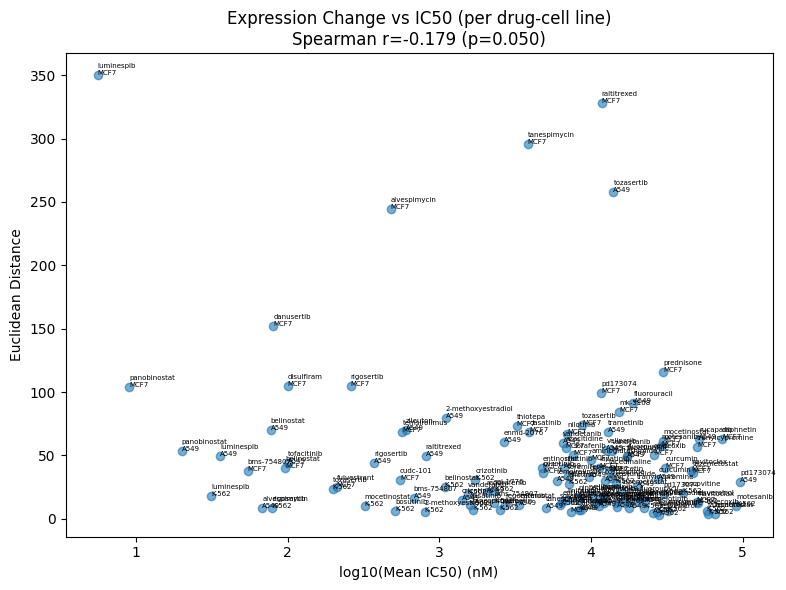

In [59]:
print(f"Drug-cell line pairs: {len(corr_df)}")

r, p = stats.spearmanr(corr_df["euclidean_dist"], corr_df["log_ic50"])
plt.figure(figsize=(8, 6))
plt.scatter(corr_df["log_ic50"], corr_df["euclidean_dist"], alpha=0.6)
for _, row in corr_df.iterrows():
    plt.annotate(f"{row['drug_norm']}\n{row['cell_line']}", (row["log_ic50"], row["euclidean_dist"]), fontsize=5)
plt.xlabel("log10(Mean IC50) (nM)")
plt.ylabel("Euclidean Distance")
plt.title(f"Expression Change vs IC50 (per drug-cell line)\nSpearman r={r:.3f} (p={p:.3f})")
plt.tight_layout()
plt.show()